-----
# **Mental Health & Social Media Analytics(EDA)**
------


<h1 style="font-family: 'poppins'; font-weight: bold; color: #1addff;">Author: Danish Javaid Meo</h1>

[![Email](https://img.shields.io/badge/Email-Contact%20Me-red?style=for-the-badge&logo=email)](danishjmeo@gmail.com)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-blue?style=for-the-badge&logo=kaggle)](https://www.kaggle.com/danishjmeo)
[![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/danishmeo9) 
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/danish-javaid-4271a8231/)  


### **Column Description**
| Column | Type | Description |
|---|---|---|
| Teen_ID | Integer | Unique identifier assigned to each participant |
| Age | Integer | Age of the teenager (13–19 years) |
| Gender | Categorical | Gender of the participant (Male/Female) |
| Social_Media_Hours | Float | Average daily hours spent on social media |
| Preferred_Platform | Categorical | Primary platform used (Instagram, TikTok, Both) |
| Sleep_Hours | Float | Average daily sleep duration |
| Physical_Activity_Level | Integer | Physical activity frequency/engagement score |
| Academic_Performance | Float | Academic achievement / GPA-related score |
| Stress_Level | Integer | Self-reported stress level (1–10 scale) |
| Anxiety_Level | Integer | Self-reported anxiety level (1–10 scale) |
| Depression_Label | Binary | Depression status (0 = Not Depressed, 1 = Depressed) |

# **Import Libraries**

In [1]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore') 

# **Load Data Set**

In [2]:

df=pd.read_csv("./Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# **Structural Composition**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [4]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


# **Missing Values**

In [5]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

# **Severity Level Categorization**

In [6]:

bins = [0, 3, 6, 8, 10]
labels = ["Low", "Moderate", "High", "Very High"]

# Stress Level
df["Stress_Category"] = pd.cut(
    df["stress_level"],
    bins=bins,
    labels=labels
)

# Anxiety Level
df["Anxiety_Category"] = pd.cut(
    df["anxiety_level"],
    bins=bins,
    labels=labels
)

# Addiction Level
df["Addiction_Category"] = pd.cut(
    df["addiction_level"],
    bins=bins,
    labels=labels
)


**Risk tier thresholds** (adjustable based on resource constraints):
| Tier | Probability Range | Action |
|------|------------------|--------|
| 🟢 **Low Risk** | 0 – 20% | Standard monitoring |
| 🟡 **Moderate Risk** | 20 – 50% | Counsellor check-in recommended |
| 🔴 **High Risk** | 50%+ | Immediate mental health screening |

In [7]:
df["depression_label"] = df["depression_label"].map({
    0: "No Depression",
    1: "Depression"
})

-----

# **Value Counts & Percent Dist of Categorical Columns**

In [8]:
for col in df.select_dtypes(include=["object", "category"]).columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(pd.concat([
        df[col].value_counts(dropna=False),
        df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    ], axis=1, keys=["Count", "Percentage"]))


Column: gender
        Count  Percentage
gender                   
male      615       51.25
female    585       48.75

Column: platform_usage
                Count  Percentage
platform_usage                   
Instagram         411       34.25
TikTok            398       33.17
Both              391       32.58

Column: social_interaction_level
                          Count  Percentage
social_interaction_level                   
medium                      416       34.67
low                         415       34.58
high                        369       30.75

Column: depression_label
                  Count  Percentage
depression_label                   
No Depression      1169       97.42
Depression           31        2.58

Column: Stress_Category
                 Count  Percentage
Stress_Category                   
Moderate           382       31.83
Low                358       29.83
Very High          250       20.83
High               210       17.50

Column: Anxiety_Category
 

# **Numeric Columns**

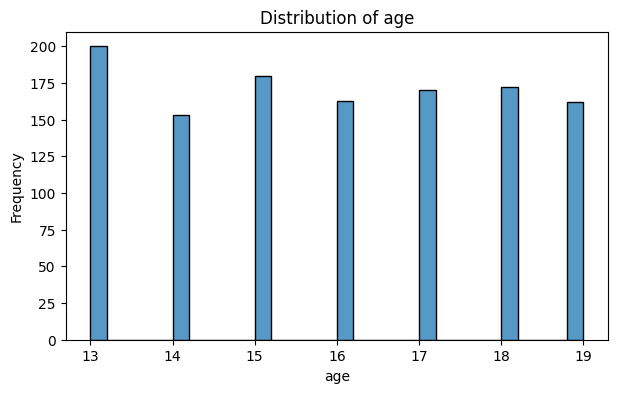

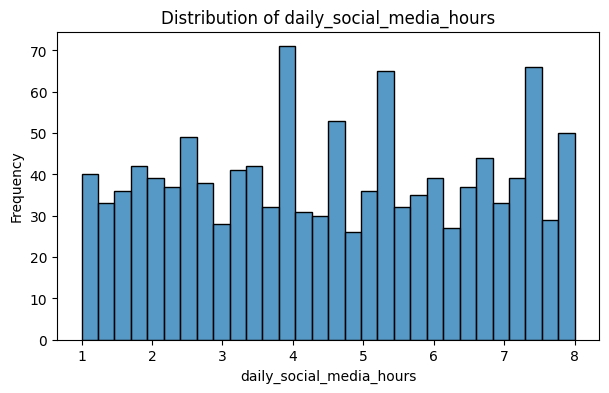

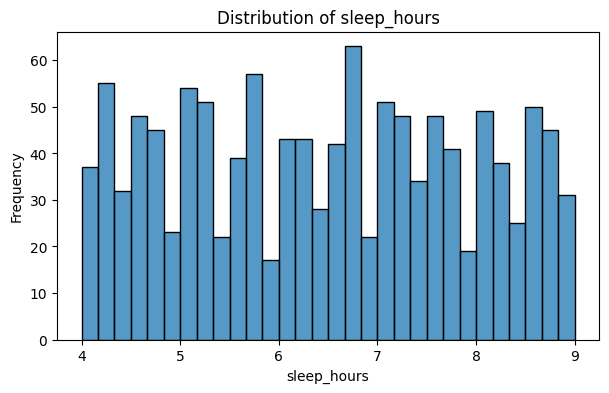

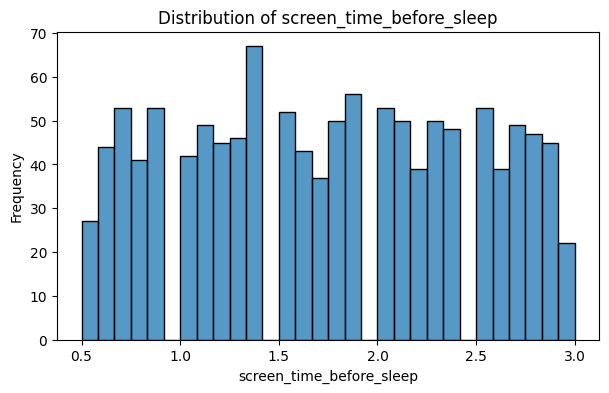

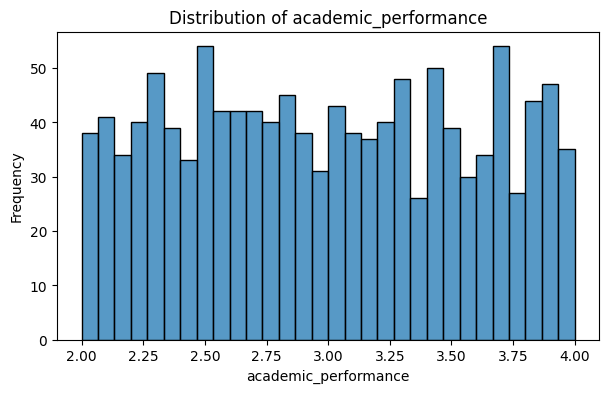

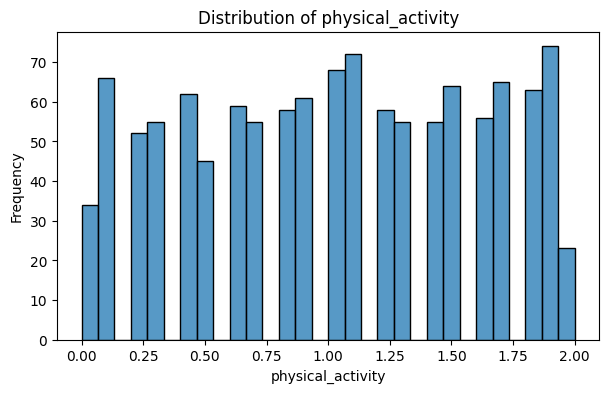

In [9]:

cols = [
    "age",
    "daily_social_media_hours",
    "sleep_hours",
    "screen_time_before_sleep",
    "academic_performance",
    "physical_activity"
]
for col in cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

---

# **Correlation Matrix**

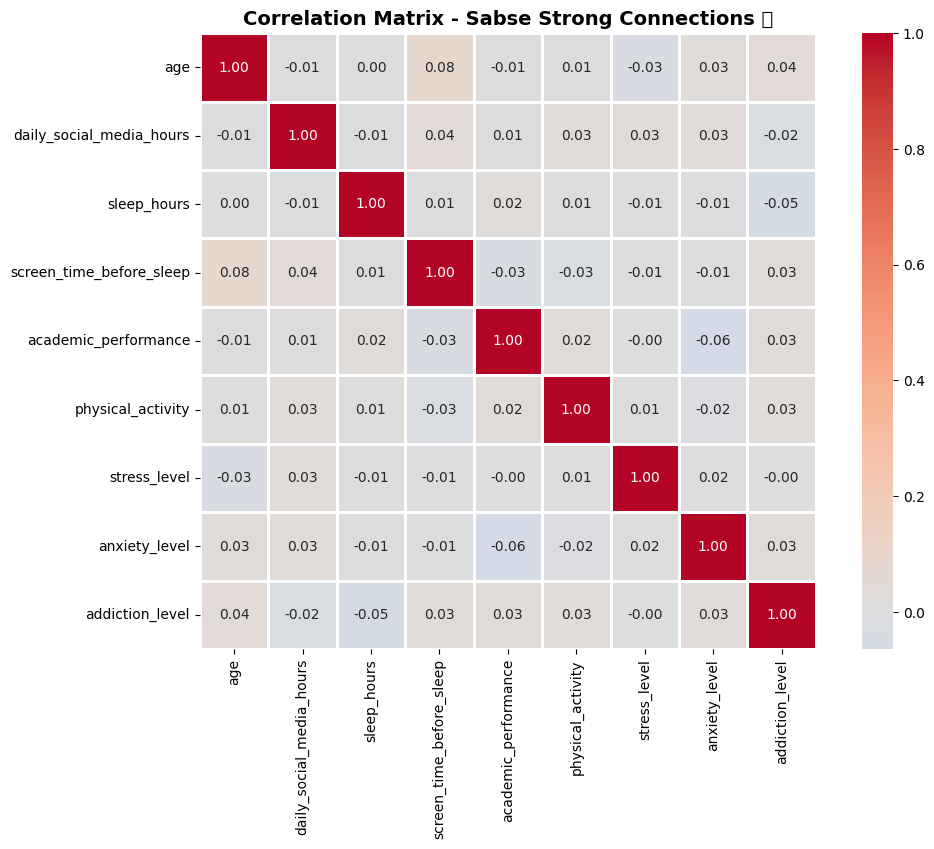


🏆 TOP POSITIVE CORRELATIONS:
daily_social_media_hours  daily_social_media_hours    1.0
anxiety_level             anxiety_level               1.0
stress_level              stress_level                1.0
physical_activity         physical_activity           1.0
screen_time_before_sleep  screen_time_before_sleep    1.0
dtype: float64

🏆 TOP NEGATIVE CORRELATIONS:
anxiety_level         academic_performance       -0.064379
academic_performance  anxiety_level              -0.064379
addiction_level       sleep_hours                -0.054838
sleep_hours           addiction_level            -0.054838
academic_performance  screen_time_before_sleep   -0.034715
dtype: float64


In [10]:

# Select numerical columns only for correlation
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=1, square=True)
plt.title('Correlation Matrix - Sabse Strong Connections 🔗', fontsize=14, fontweight='bold')
plt.show()

# Top correlations
print("\n🏆 TOP POSITIVE CORRELATIONS:")
print(correlation_matrix.unstack().sort_values(ascending=False)[1:6])  # Skip self-correlation

print("\n🏆 TOP NEGATIVE CORRELATIONS:")
print(correlation_matrix.unstack().sort_values()[0:5])

## **Distribution of Depression, Stress, and Anxiety Categories**

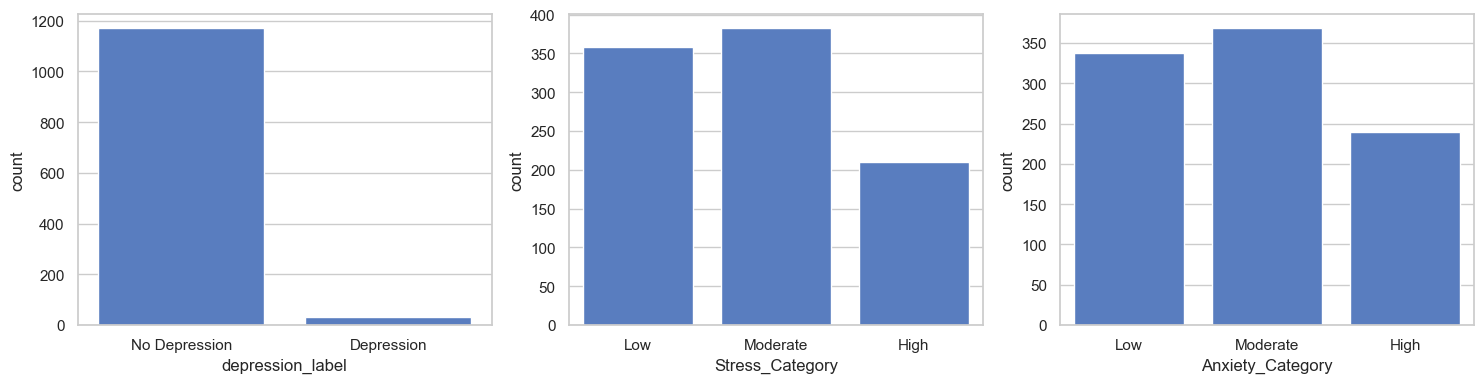

In [11]:

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(data=df, x='depression_label', ax=axes[0])
sns.countplot(data=df, x='Stress_Category', ax=axes[1], order=['Low','Moderate','High'])
sns.countplot(data=df, x='Anxiety_Category', ax=axes[2], order=['Low','Moderate','High'])
plt.tight_layout()

## 🔍 Key Observations
- Fewer than 100 teens in the dataset are labeled as depressed — the classes are highly imbalanced.
- The **Moderate** stress category is the most common, showing most teens fall in the mid-range of the stress scale.
- The **Moderate** anxiety category is also the most common, showing most teens fall in the mid-range of the anxiety scale.

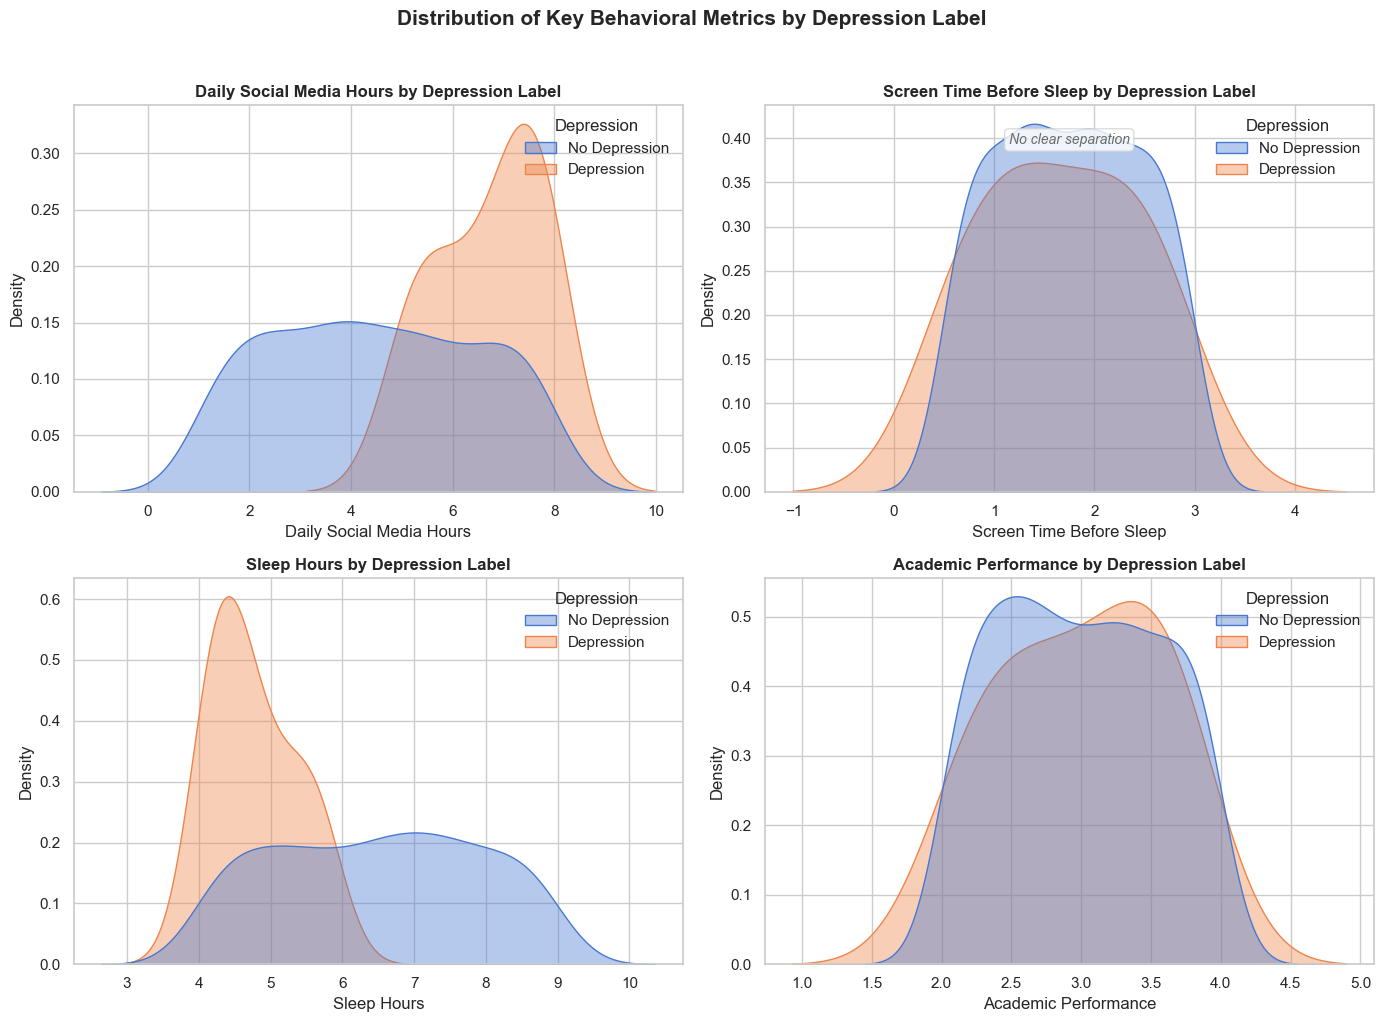

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

cols = ['daily_social_media_hours', 'screen_time_before_sleep', 
        'sleep_hours', 'academic_performance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(
        data=df, x=col, hue='depression_label', 
        fill=True, common_norm=False, alpha=0.4,
        bw_adjust=1.3,
        ax=axes[i]
    )
    axes[i].set_title(f'{col.replace("_", " ").title()} by Depression Label', 
                       fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Density')

    # reposition/retitle seaborn's own legend instead of creating a new one
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('Depression')
        legend.set_bbox_to_anchor((1, 1))  # anchor to upper right of axes
        legend._loc = 1  # matplotlib internal code for 'upper right'

axes[1].text(
    0.5, 0.9, 'No clear separation', transform=axes[1].transAxes,
    ha='center', fontsize=10, style='italic', color='dimgray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=0.8)
)

plt.suptitle('Distribution of Key Behavioral Metrics by Depression Label', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔍 Key Observations

- **Daily social media hours** shows the strongest separation between groups — the Depression group clusters around 7–8 hours/day, while the No Depression group peaks at 2–4 hours, with limited overlap.
- **Sleep hours** shows the inverse and equally strong pattern — Depression cases cluster tightly around 4–5 hours of sleep, while No Depression cases spread more evenly across 6–9 hours.
- **Screen time before sleep** shows near-complete overlap between groups, meaning this variable alone has weak discriminative power for depression status.
- **Academic performance** shows only a mild shift between groups — depression status in this dataset doesn't simply track with poor academic outcomes.


In [ ]:

cat_vars = ['Stress_Category', 'Anxiety_Category', 'Addiction_Category', 'depression_label']
titles = ['Stress Level', 'Anxiety Level', 'Addiction Level', 'Depression Label']
level_order = ['Low', 'Moderate', 'High']

# dynamically map colors to whatever genders actually exist — no silent fallback
genders_present = sorted(df['gender'].dropna().unique().tolist())
palette_cycle = px.colors.qualitative.Set2
colors = {g: palette_cycle[i % len(palette_cycle)] for i, g in enumerate(genders_present)}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=titles,
    horizontal_spacing=0.12, vertical_spacing=0.22
)

positions = [(1,1), (1,2), (2,1), (2,2)]

for var, (r, c) in zip(cat_vars, positions):
    grouped = df.groupby([var, 'gender']).size().reset_index(name='count')
    grouped['pct'] = grouped.groupby(var)['count'].transform(lambda x: x / x.sum() * 100)

    cats_present = grouped[var].unique().tolist()
    order = [lvl for lvl in level_order if lvl in cats_present] or sorted(cats_present)

    for gender in genders_present:
        sub = grouped[grouped['gender'] == gender].set_index(var).reindex(order).reset_index()
        fig.add_trace(
            go.Bar(
                x=sub[var], y=sub['pct'], name=gender,
                marker_color=colors[gender],
                showlegend=(r, c) == (1, 1),
                text=sub['pct'].round(1).astype(str) + '%',
                textposition='outside',
                cliponaxis=False,          # never clip text at plot edge
                legendgroup=gender
            ),
            row=r, col=c
        )
    # add headroom above tallest bar so labels have room
    max_pct = grouped['pct'].max()
    fig.update_yaxes(range=[0, max_pct * 1.25], row=r, col=c)

fig.update_layout(
    barmode='group',
    template='plotly_white',
    title=dict(text='Gender Distribution Across Psychological & Behavioral Categories',
               font=dict(size=19, family='Arial Black'), x=0.5),
    font=dict(family='Arial', size=12),
    legend_title_text='Gender',
    height=750, width=950,
    margin=dict(t=100),
    uniformtext_minsize=9, uniformtext_mode='hide'
)

fig.update_yaxes(ticksuffix='%', title_text='Percentage')
fig.show()

----